## Instance Segmentation

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!rm -rf "./train.zip"
!rm -rf "./validation.zip"
!rm -rf "../data"

!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/train.zip"
!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/validation.zip"

!mkdir -p "../data/train"
#!mkdir -p "../data/validation"

!unzip "train.zip" -d "../data"
!unzip "validation.zip" -d "../data"

!mv "../data/train_combined/images/" "../data/train/"
!mv "../data/train_combined/masks/" "../data/train/"
!rm -rf "../data/train_combined/"

Streaming output truncated to the last 5000 lines.
  inflating: ../data/train_combined/masks/4_run2_mask_00072.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00073.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00076.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00077.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00078.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00079.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00080.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00081.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00082.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00083.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00084.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00085.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00086.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00089.png  
  inflating: ../data/trai

## Data Loading

In [3]:
import glob
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [4]:
train_dir = "../data/train"
valid_dir = "../data/validation"

In [5]:
train_images_paths, train_masks_paths = shuffle(glob.glob(train_dir+"/images/*.jpeg"), glob.glob(train_dir+"/masks/*.png"), random_state=42)
#train_masks_paths = glob.glob(train_dir+"/masks/*.png")

valid_images_paths, valid_masks_paths = shuffle(glob.glob(valid_dir+"/images/*.jpeg"), glob.glob(valid_dir+"/masks/*.png"), random_state=42)

assert len(train_images_paths) == len(train_masks_paths)
assert len(valid_images_paths) == len(valid_masks_paths)

In [6]:
print(f"Total train images is {len(train_images_paths)}")
print(f"Total validation images is {len(valid_images_paths)}")

Total train images is 4131
Total validation images is 1184


In [7]:
def load_images(path_list):
    loaded_images = []
    for path in path_list:
        loaded_images.append(cv2.imread(path))
    return np.array(loaded_images)

train_images = load_images(train_images_paths)
train_masks = load_images(train_masks_paths)
valid_images = load_images(valid_images_paths)
valid_masks = load_images(valid_masks_paths)

In [8]:
print(f"Train images shape is {train_images.shape}")
print(f"Train masks shape is {train_masks.shape}")
print(f"Valid images shape is {valid_images.shape}")
print(f"Valid masks shape is {valid_masks.shape}")

Train images shape is (4131, 256, 256, 3)
Train masks shape is (4131, 256, 256, 3)
Valid images shape is (1184, 256, 256, 3)
Valid masks shape is (1184, 256, 256, 3)


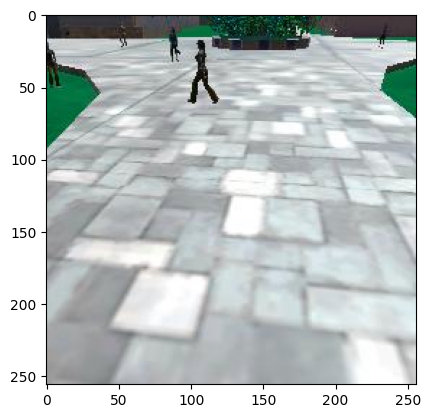

In [9]:
# Visual representation of data
plt.imshow(train_images[0])

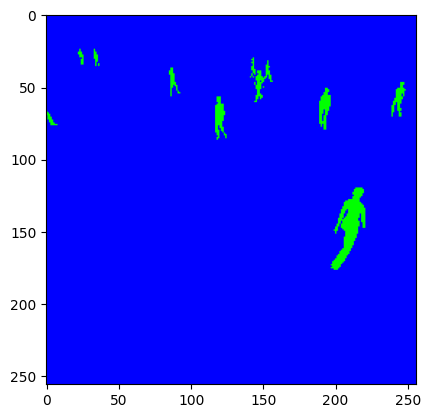

In [10]:
plt.imshow(train_masks[0])

In [11]:
#print(train_masks[1][10:11])
# From here I can see how the segmentation is done on this dataset in that:
# red is the person of interest [255, 0, 0]
# blue is the uninterested region [0, 0, 255]
# green is the people class [0, 255, 0]

In [12]:
def preprocess(images):
    return images/255.0

In [13]:
train_masks = np.array(train_masks/255.0, dtype=np.int8)#preprocess(train_masks)
valid_images = np.array(valid_masks/255.0, dtype=np.int8)#preprocess(valid_masks)

In [14]:
train_images = train_images/255.0

In [15]:
valid_images = valid_images/255.0

## Defining model

In [16]:
from keras.models import Model
from keras.layers import Conv2D, Input, UpSampling2D, Concatenate, GlobalAveragePooling2D, UpSampling2D, Reshape, BatchNormalization
from keras.applications import ResNet50, MobileNetV2

In [17]:
"""
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
for i in base.layers:
    print(i.name)
#output =
"""

'\nbase = ResNet50(\n    weights="imagenet",\n    include_top=False,\n    input_shape=(256, 256, 3)\n)\nfor i in base.layers:\n    print(i.name)\n#output =\n'

In [18]:
input_shape = (256, 256, 3)
trainable = False
def conv_block(inputs, filters, dilation_rate=1, kernel_size=3, stride=1):
    print("work_conv")
    x = Conv2D(filters, kernel_size, (stride, stride), padding="same", use_bias=False, dilation_rate=(dilation_rate, dilation_rate))(inputs)
    x = BatchNormalization()(x)
    return tf.nn.relu(x)

In [19]:
def base_model(inputs, input_shape=(256, 256, 3), trainable=False):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        #input_shape=input_shape,
        input_tensor=inputs
    )
    base.trainable = trainable
    return base

In [20]:
def ASPP(input_tensor):
    shape = input_tensor.shape
    print("Start")
    layer1 = conv_block(input_tensor, 256, 1, 1, 1)
    layer2 = conv_block(input_tensor, 256, 6, 3, 1)
    layer3 = conv_block(input_tensor, 256, 12, 3, 1)
    layer4 = conv_block(input_tensor, 256, 18, 3, 1)
    layer5 = GlobalAveragePooling2D()(input_tensor)
    layer5 = Reshape((1, 1, layer5.shape[-1]))(layer5)
    layer5 = conv_block(layer5, 256, kernel_size=1)
    layer5 = UpSampling2D(
        size=(shape[1], shape[2]), interpolation="bilinear")(layer5)
    layers_add = Concatenate()([layer1, layer2, layer3, layer4, layer5])
    output = conv_block(layers_add, 256, 1, 1, 1)
    print("End")
    return output

In [ ]:
def encoder(base):
    layers = [
        "conv2_block3_out",
        "conv4_block6_out"
    ]
    layers = [base.get_layer(name).output for name in layers]
    #model_input = base_model(input_tensor, input_shape=input_shape, trainable)
    #model_ouput = ASPP(model_input)
    #encoder_model = Model(model_input, model_output)
    model = Model(base.input, layers)
    return model

In [ ]:
def decoder(base_input, ASPP_input):
    layer1 = UpSampling2D(size=(4, 4), interpolation="bilinear")(ASPP_input)
    layer_add = Concatenate(base_input, layer1)
    layer3 = conv_block(layer_add, 256, 1, 3, 1)
    output = UpSampling2D(size=(4, 4), interpolation="bilinear")(layer3)
    return output

In [ ]:
def deeplabv3plus(num_classes=3):
    inputs = Input(shape=input_shape)
    base = base_model(inputs, input_shape=input_shape, trainable=trainable)
    encoder_output = encoder(base)
    low_level, base_output = encoder_output.output
    aspp_out = ASPP(base_output)

    low_level = conv_block(low_level, 48, 1, 1, 1)
    decoder_out = decoder(low_level, aspp_out)
    output = Conv2D(num_classes, 1, padding="same")(decoder_out)
    model = Model(inputs=inputs, outputs=output)
    return model

In [ ]:
model = deeplabv3plus()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


## Training and Testing

In [ ]:
learning_rate = 1e-5
epochs = 40

In [ ]:
# Dice Loss and cross entropy loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    d_loss = (2 * intersection + smooth) / (union + smooth)
    return d_loss

cross_entropy_loss = tf.keras.losses.CategoricalCrossentropy()


def total_loss(y_true, y_pred):
  return dice_loss(y_true, y_pred) + cross_entropy_loss

In [ ]:
# meen IoU
def meanIoU():
    return mIoU

In [ ]:
model.compile(
    optimizer="adam",
    loss=total_loss,
    metrics="accuracy"
)

AttributeError: 'function' object has no attribute 'compile'

In [ ]:
model.fit(
    X_train, y_train,
    learning_rate,
)